In [1]:
import numpy as np
import sympy as smp
from scipy.integrate import odeint
import matplotlib.pyplot as plt

In [2]:
t, m, b, g = smp.symbols('t m b g')
S, I, R = smp.symbols('S I R', cls=smp.Function)
S = S(t)
I = I(t)
R = R(t)
I_d = smp.diff(I, t)
S_d = smp.diff(S, t)
R_d = smp.diff(R, t)

In [3]:
S_d = -m*S*I 
I_d = m*S*I - g*I
R_d = g*I

S_f = smp.lambdify([m,S,I], S_d)
I_f = smp.lambdify([m, g, S,I], I_d)
R_f = smp.lambdify([g,I], R_d)

In [4]:
def sol(W, t):
    return [
        S_f(m, W[0], W[1]),
        I_f(m, g, W[0], W[1]),
        R_f(g, W[1])
    ] 

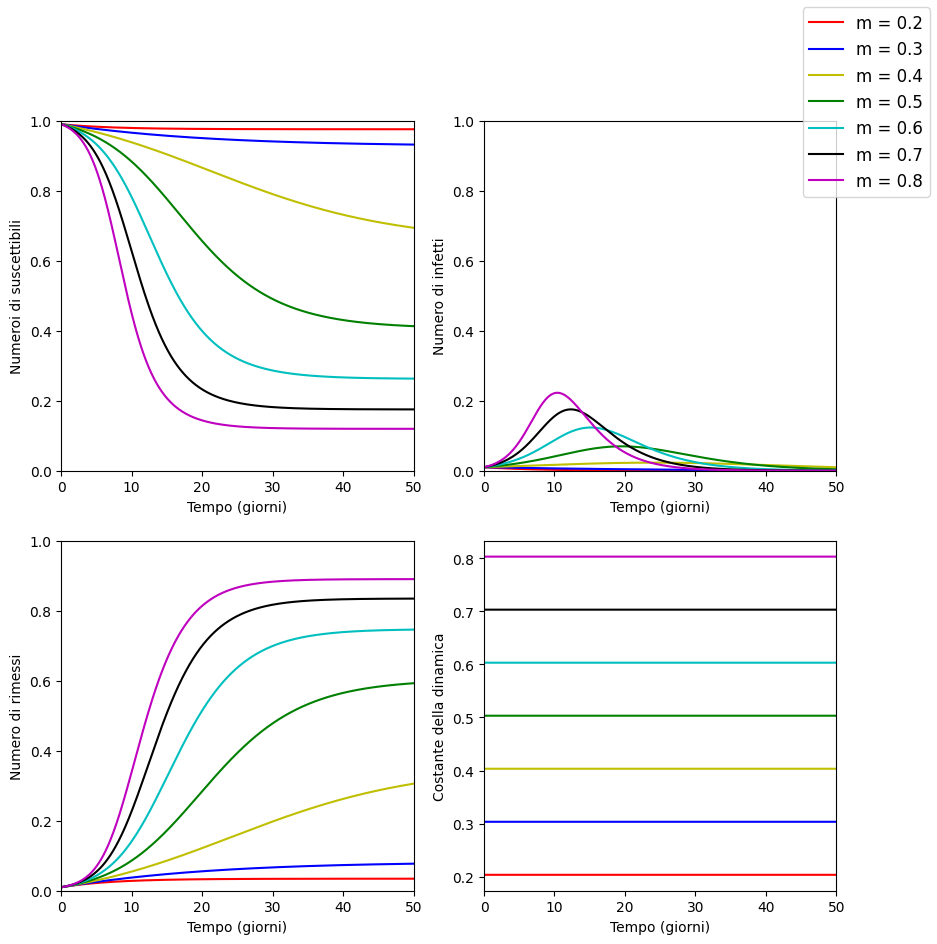

In [13]:
t = np.linspace(0, 200, 10000)
steps_m = list(np.arange(0.2, 0.9, 0.1))
index = list(np.arange(0, len(steps_m)))


fig, plot = plt.subplots(nrows = 2, ncols = 2, figsize = (10, 10))

plot[0,0].set_xlabel('Tempo (giorni)')
plot[0,0].set_ylabel('Numeroi di suscettibili')
plot[0,0].set_ylim([0,1])
plot[0,0].set_xlim([0,50])

plot[0,1].set_xlabel('Tempo (giorni)')
plot[0,1].set_ylabel('Numero di infetti')
plot[0,1].set_ylim([0,1])
plot[0,1].set_xlim([0,50])

plot[1,0].set_xlabel('Tempo (giorni)')
plot[1,0].set_ylabel('Numero di rimessi')
plot[1,0].set_ylim([0,1])
plot[1,0].set_xlim([0,50])

plot[1,1].set_xlabel('Tempo (giorni)')
plot[1,1].set_ylabel('Costante della dinamica')
plot[1,1].set_xlim([0,50])

solutions = []
constant = []
colours = ['r', 'b', 'y', 'g', 'c', '0', 'm']

for i in steps_m:
    m = i
    g = 1/3
    solution = odeint(sol, [0.99,0.01,0.01], t)
    solutions.append(solution)
    
    I = m * (solution.T[0] + solution.T[1]) - g * np.log(solution.T[0])
    constant.append(I)

for j in index:
    suscettibili = np.where(solutions[j].T[0] == 0, 1e-10, solutions[j].T[0])  # Evita log di zero
    cost = steps_m[j] * b * (solutions[j].T[0] + solutions[j].T[1]) - g * np.log(suscettibili)
    constant.append(cost)  # Ora 'cost' è un array della stessa lunghezza di 't'



for soluzione, costante, indice, colour in zip(solutions, constant, index, colours):
    plot[0,0].plot(t, soluzione.T[0], c = colour, label = f'm = {steps_m[indice]:.1f}')
    plot[0,1].plot(t, soluzione.T[1], c = colour)
    plot[1,0].plot(t, soluzione.T[2], c = colour)
    plot[1,1].plot(t, costante, c = colour)
    
fig.legend(fontsize = 12)

fig.savefig('SIR.png')